# SABR Certification Course 3: Module 10

*Player Projections, MARCEL, and the final assignment*

In the last module, we covered some of the basics of predictive modeling in the context of team projections. We looked at building simple linear models that predict the team win total, as well as how to evaluate those models and improve them.

This time, we're going to talk about player projections. They're more complicated for a few reasons:
1. Players don't all get the same amount of playing time (whereas teams all play the same number of games).
2. Players can have missing or incomplete data.
3. Players age.

All of this gives rise to a much more complex player projection process, and we're going to cover the most basic projection system in baseball, MARCEL. A sabermetrician named Tom Tango came up with the idea of MARCEL, and it is essentially a basic linear model to predict player performance with two extra tweaks: some _regression to the mean_, as well as an _aging adjustment_.

Finally, I'm going to challenge you to calculate a simple set of MARCEL projections and then figure out how to beat MARCEL, using either a different, new set of data or a better method. Let's do it.

**MARCEL the Monkey**

Way back, quite a long time ago, a statistician named Tom Tango (who now works for MLB) developed a simple toy projection system he called MARCEL the Monkey. The idea for MARCEL was to generate the simplest possible projections, eschewing any fancy systems or extraneous data and just doing the bare minimum to build a decent prediction for what a player might accomplish in the following years.

MARCEL uses the last three years of data from a player and some fixed weights: conventionally (5, 4, 3), meaning you weight the last season 5, the second-to-last season 4, and the third-to-last season 3. Fundamentally, this is the same as a linear model that we've already learned about, think of the formula like this:

`predicted_performance = 5 * last year's performance + 4 * two years ago + 3 * three years ago`

It applies a handful of small adjustments that we'll cover one by one in the next sections, and voila, you have a system that's relatively accurate for what it is.

Performance of MARCEL kept up with the "more advanced" systems for a few years after its advent, but modern systems are much more complex and better than they were a few years ago. They can take into account things like fastball velocity or exit velocity, and they can use many years of data, even going back to a player's prospect or minor league days. They also use more sophisticated methodologies than linear models, which makes them perform better.

**Regression to the mean**

One of the key concepts in MARCEL is _regression to the mean_, which is a term you may have heard of before. Regression to the mean reflects the idea that every performance, whether it's a player's seasonal OPS, the team's win total, or even your height, is really a combination of two factors:

`observed performance = intrinsic factors + luck`

If a player hit 60 HR one season, it's likely a combination of them being really good at hitting home runs, and some amount of luck. What do we mean by luck? Luck is kind of a catch-all for a bunch of factors we don't know about but which are extrinsic or _outside_ the player themself. It could be favorable gusts of wind that happened to push a few batted balls over the fence, or perhaps favorable pitch locations that helped them knock a couple extra dingers on balls down the middle, or maybe lucky umpire calls that helped them get into hitters' counts.

But the key thing is that whatever that luck was, if you are trying to predict next year's numbers, you should expect the player to be just a little bit _less lucky_ than they were before. The intrinsic factors, like the player's strength or hand-eye coordination, may still be there, but the gusts of wind and lucky pitches down the middle will not.

So, when we go to predict next year's home run total, we automatically price in some regression back towards the league average. Exactly how much regression depends on the model you build. The more you are able to take into account those extrinsic factors or what we call "luck," the better you may be able to predict a player's likeliest production next year.

For MARCEL, we calculate a number called _reliability_ that corresponds to the extent to which we want to regress a player's statistics to the mean. A player with high _reliability_ goes back towards the mean (high or low) less than a player with low reliability.

```
reliability = total PA / (total PA + 1200)
Regressed rate = (Player reliability * Player Rate) + ((1 – Player reliability) * league average)
```


Quick note here: in this formula, the total PA and Player Rate are over the last three seasons, so the sum of all PA in those three years and the average of their (in this case) OPS.

MARCEL adds regression to the mean in a very simple manner: it includes a _reliability_ factor that depends on how many PA a player had in their three prior seasons. If a player had full seasons each year, then we know more about their intrinsic ability than if they only racked up 150 PA. In the former case, we don't need to regress their ability very much. In the latter, we need to regress it a lot. We always regress to the league average. So if a player is lower than expected, they "regress" upwards. (This is a very counter-intuitive usage of the word "regress," so take note!)

**Age adjustment**

As you've hopefully picked up on by now, one of the most critical elements of a player's predicted performance is their age. Younger players tend to perform better in following seasons because they aren't fighting off Father Time. Older players, by contrast, often see their production decline, as their physical abilities begin to slip and they often contend with injuries.

To account for this, MARCEL uses an age adjustment. It's a flat factor that depends on how many years away from a player's prime they are. The older they are, the worse MARCEL expects them to do. The younger they are--up to their prime age, as defined by MARCEL as age 28--the _better_ they are expected to do.

The adjustment is applied as a simple multiplier. So, for a given age, your expected production either gets multiplied above 1 (increasing it) or below 1 (decreasing it). The multiplier looks like this:


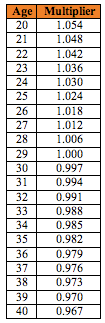

**A quick note on reading and writing data**

One thing we haven't covered before is reading and writing data to .csv format, which you'll need to do for the assignment. It's very simple using the Tidyverse, just the `read_csv` and `write_csv` commands. These will take in or write out data in csv format. You can manage local files in Google Colab by looking at the file tab, which is in the upper left (third icon from the top in the leftmost rail):
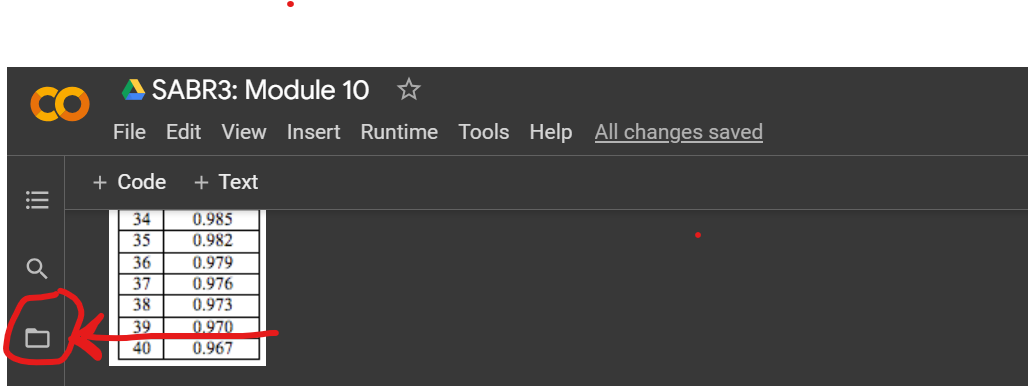

In [ ]:
library(tidyverse)
data = read_csv("https://huggingface.co/spaces/rkarthur/sabr3evaluation/raw/main/data/SABR3_Final_Assignment_data.csv")
head(data)
#write_csv(data, "testing_data.csv")

Rows: 167 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): bbref_id
dbl (9): Age, PA1, PA2, PA3, PA4, OPSY1, OPSY2, OPSY3, OPSY4

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


bbref_id,Age,PA1,PA2,PA3,PA4,OPSY1,OPSY2,OPSY3,OPSY4
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
abreujo02,33,262,693,553,675,0.987,0.8340000,0.798,0.906
adriaeh01,30,101,236,366,186,0.557,0.7650000,0.680,0.707
aguilje01,30,216,738,566,311,0.809,0.7135691,0.890,0.837
ahmedni01,30,217,625,564,178,0.729,0.7530000,0.700,0.717
albieoz01,23,124,702,684,244,0.773,0.8520000,0.757,0.810
alfarjo01,27,100,465,377,114,0.624,0.7360000,0.731,0.874


In [ ]:
if (!requireNamespace('devtools', quietly = TRUE)){
  install.packages('devtools')
}
devtools::install_github(repo = "BillPetti/baseballr")

Skipping install of 'baseballr' from a github remote, the SHA1 (1758bf8a) has not changed since last install.
  Use `force = TRUE` to force installation



In [ ]:
library(baseballr)

In [ ]:
install.packages("RSQLite")
library(RSQLite)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘plogr’




In [ ]:
player_rate = ((data$OPSY1*3) + (data$OPSY2*4) + (data$OPSY3*5))/12
reliability = (data$PA1 + data$PA2 + data$PA3)/((data$PA1 + data$PA2 + data$PA3) + 1200)
regressed_rate = (reliability * player_rate) + ((1 - reliability) * .720)
data_w_regressed_rate = data%>%mutate(regressedrate = regressed_rate)

#proj_under_29
#proj_over_29 = data_w_regressed_rate%>%filter(Age > 29)%>%mutate(projected_OPS= (1 + (Age-29)*-.03)*regressed_rate)

In [ ]:
data_w_regressed_rate <- as.data.frame(data_w_regressed_rate)

In [ ]:
projs <- c()
for (player in data_w_regressed_rate$bbref_id){
  player_data = data_w_regressed_rate%>%filter(bbref_id == player)
  if(player_data$Age < 29){
    projs <- c(projs, (1 + ( 29 - player_data$Age)*.06)*player_data$regressedrate)
  }
  else if(player_data$Age > 29) {
    projs<- c(projs, (1 + (player_data$Age - 29)*(-.03))*player_data$regressedrate)
  }
  else {
    projs<- c(projs, player_data$regressedrate)
  }
}

In [ ]:
data_w_regressed_rate$projected_OPS_nextyr <- projs

In [ ]:
install.packages("Lahman")
library(Lahman)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
Lahman <- Lahman::Batting %>% filter((yearID > 2017) & (yearID < 2022))
Lahman <- Lahman[Lahman$playerID %in% data_w_regressed_rate$bbref_id, ]
colnames(Lahman)

[1] "playerID" "yearID"   "stint"    "teamID"   "lgID"     "G"       
 [7] "AB"       "R"        "H"        "X2B"      "X3B"      "HR"      
[13] "RBI"      "SB"       "CS"       "BB"       "SO"       "IBB"     
[19] "HBP"      "SH"       "SF"       "GIDP"

In [ ]:
Lahman <- Lahman%>%mutate(overall_hitting = ((H + SF + BB +  IBB + HBP)/AB) - (SO/AB))


In [ ]:
Lahman <- Lahman%>%group_by(playerID, yearID)%>%summarise(overall_hitting_metric = mean(overall_hitting))

`summarise()` has grouped output by 'playerID'. You can override using the
`.groups` argument.


In [ ]:
twen8_hitting <- Lahman%>%filter(yearID==2018)
data_w_regressed_rate$yr1hitting <- twen8_hitting$overall_hitting_metric

In [ ]:
identical(data_w_regressed_rate$bbref_id, twen8_hitting$playerID)

[1] TRUE

In [ ]:
twen9_hitting <- Lahman%>%filter(yearID==2019)
data_w_regressed_rate$yr2hitting <- twen9_hitting$overall_hitting_metric

In [ ]:
twen20_hitting <- Lahman%>%filter(yearID==2020)
data_w_regressed_rate$yr3hitting <- twen20_hitting$overall_hitting_metric

In [ ]:
statcast_batters <- scrape_savant_leaderboards(leaderboard = 'exit_velocity_barrels', year = 2020, player_type = 'batter', min_pa = 100)

In [ ]:
#batters <- statcast_leaderboards(leaderboard = "exit_velocity_barrels", year = 2020)

In [ ]:
#batters <- data.frame(batters)

In [ ]:
database_connection <- DBI::dbConnect(RSQLite::SQLite(), "new_database.db")

In [ ]:
people_db = Lahman::People
people_db$name_full = paste(Lahman::People$nameLast, Lahman::People$nameFirst, sep=", ")
#dbWriteTable(database_connection, "Lahmanpeople", as.data.frame(people_db))
#dbWriteTable(database_connection, "OPSdata", data_w_regressed_rate)

In [ ]:
head(people_db)

,playerID,birthYear,birthMonth,birthDay,birthCountry,birthState,birthCity,deathYear,deathMonth,deathDay,⋯,height,bats,throws,debut,finalGame,retroID,bbrefID,deathDate,birthDate,name_full
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,⋯,<int>,<fct>,<fct>,<chr>,<chr>,<chr>,<chr>,<date>,<date>,<chr>
1,aardsda01,1981,12,27,USA,CO,Denver,NA,NA,NA,⋯,75,R,R,2004-04-06,2015-08-23,aardd001,aardsda01,NA,1981-12-27,"Aardsma, David"
2,aaronha01,1934,2,5,USA,AL,Mobile,2021,1,22,⋯,72,R,R,1954-04-13,1976-10-03,aaroh101,aaronha01,2021-01-22,1934-02-05,"Aaron, Hank"
3,aaronto01,1939,8,5,USA,AL,Mobile,1984,8,16,⋯,75,R,R,1962-04-10,1971-09-26,aarot101,aaronto01,1984-08-16,1939-08-05,"Aaron, Tommie"
4,aasedo01,1954,9,8,USA,CA,Orange,NA,NA,NA,⋯,75,R,R,1977-07-26,1990-10-03,aased001,aasedo01,NA,1954-09-08,"Aase, Don"
5,abadan01,1972,8,25,USA,FL,Palm Beach,NA,NA,NA,⋯,73,L,L,2001-09-10,2006-04-13,abada001,abadan01,NA,1972-08-25,"Abad, Andy"
6,abadfe01,1985,12,17,D.R.,La Romana,La Romana,NA,NA,NA,⋯,74,L,L,2010-07-28,2021-10-01,abadf001,abadfe01,NA,1985-12-17,"Abad, Fernando"


In [ ]:
head(data_w_regressed_rate)

,bbref_id,Age,PA1,PA2,PA3,PA4,OPSY1,OPSY2,OPSY3,OPSY4,regressedrate,projected_OPS_nextyr,yr1hitting,yr2hitting,yr3hitting
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,abreujo02,33,262,693,553,675,0.987,0.8340000,0.798,0.906,0.7964302,0.7008586,0.16833667,0.14353312,0.16666667
2,adriaeh01,30,101,236,366,186,0.557,0.7650000,0.680,0.707,0.7043306,0.6832007,0.09253731,0.22772277,0.06741573
3,aguilje01,30,216,738,566,311,0.809,0.7135691,0.890,0.837,0.7708192,0.7476947,0.14024390,0.15545437,0.21276596
4,ahmedni01,30,217,625,564,178,0.729,0.7530000,0.700,0.717,0.7226527,0.7009731,0.11821705,0.17625899,0.12562814
5,albieoz01,23,124,702,684,244,0.773,0.8520000,0.757,0.810,0.7604895,1.0342658,0.14866980,0.22656250,0.06779661
6,alfarjo01,27,100,465,377,114,0.624,0.7360000,0.731,0.874,0.7138065,0.7994633,-0.02616279,-0.01392111,-0.07526882


In [ ]:
head(statcast_batters)

year,"last_name, first_name",player_id,attempts,avg_hit_angle,anglesweetspotpercent,max_hit_speed,avg_hit_speed,fbld,gb,max_distance,avg_distance,avg_hr_distance,ev95plus,ev95percent,barrels,brl_percent,brl_pa
<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>
2020,"Merrifield, Whit",593160,216,15.8,39.8,105.8,86.1,89.6,81.7,406,180,388,59,27.3,11,5.1,4.2
2020,"Turner, Trea",607208,199,9.5,34.2,111.2,90.5,93.3,88.7,422,166,399,81,40.7,19,9.5,7.3
2020,"Lindor, Francisco",596019,197,13.5,36.5,111.4,89.9,93.3,86.8,412,176,390,81,41.1,11,5.6,4.1
2020,"Alberto, Hanser",593643,193,13.2,32.6,103.8,82.3,88.4,79.5,391,141,381,40,20.7,2,1.0,0.9
2020,"Machado, Manny",592518,191,15.6,34.6,115.7,90.2,94.1,88.2,436,177,413,83,43.5,21,11.0,8.3
2020,"Gregorius, Didi",544369,190,17.8,35.3,104.7,83.8,90.2,79.0,417,171,385,53,27.9,8,4.2,3.4


In [ ]:
colnames(statcast_batters) <- c('year', 'last_name_first_name', 'player_id', 'attempts', 'avg_hit_angle', 'anglesweetspotpercent', 'max_hit_speed', 'avg_hit_speed', 'fbld', 'gb', 'max_distance', 'avg_distance', 'avg_hr_distance', 'ev95plus', 'ev95percent', 'barrels', 'brl_percent', 'brl_pa')

In [ ]:
head(statcast_batters)

year,last_name_first_name,player_id,attempts,avg_hit_angle,anglesweetspotpercent,max_hit_speed,avg_hit_speed,fbld,gb,max_distance,avg_distance,avg_hr_distance,ev95plus,ev95percent,barrels,brl_percent,brl_pa
<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>
2020,"Merrifield, Whit",593160,216,15.8,39.8,105.8,86.1,89.6,81.7,406,180,388,59,27.3,11,5.1,4.2
2020,"Turner, Trea",607208,199,9.5,34.2,111.2,90.5,93.3,88.7,422,166,399,81,40.7,19,9.5,7.3
2020,"Lindor, Francisco",596019,197,13.5,36.5,111.4,89.9,93.3,86.8,412,176,390,81,41.1,11,5.6,4.1
2020,"Alberto, Hanser",593643,193,13.2,32.6,103.8,82.3,88.4,79.5,391,141,381,40,20.7,2,1.0,0.9
2020,"Machado, Manny",592518,191,15.6,34.6,115.7,90.2,94.1,88.2,436,177,413,83,43.5,21,11.0,8.3
2020,"Gregorius, Didi",544369,190,17.8,35.3,104.7,83.8,90.2,79.0,417,171,385,53,27.9,8,4.2,3.4


In [ ]:
#dbWriteTable(database_connection, "statcast_2020", as.data.frame(statcast_batters))

In [ ]:
dbGetQuery(database_connection, "SELECT *
FROM OPSdata
LEFT JOIN Lahmanpeople on OPSdata.bbref_id = Lahmanpeople.bbrefID
LEFT JOIN statcast_2020 on Lahmanpeople.name_full = statcast_2020.last_name_first_name")

bbref_id,Age,PA1,PA2,PA3,PA4,OPSY1,OPSY2,OPSY3,OPSY4,⋯,fbld,gb,max_distance,avg_distance,avg_hr_distance,ev95plus,ev95percent,barrels,brl_percent,brl_pa
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>
abreujo02,33,262,693,553,675,0.987,0.8340000,0.7980000,0.9060000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
adriaeh01,30,101,236,366,186,0.557,0.7650000,0.6800000,0.7070000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
aguilje01,30,216,738,566,311,0.809,0.7135691,0.8900000,0.8370000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
ahmedni01,30,217,625,564,178,0.729,0.7530000,0.7000000,0.7170000,⋯,92.4,84.5,425,142,409,51,33.3,8,5.2,3.7
albieoz01,23,124,702,684,244,0.773,0.8520000,0.7570000,0.8100000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
alfarjo01,27,100,465,377,114,0.624,0.7360000,0.7310000,0.8740000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
altuvjo01,30,210,548,599,662,0.629,0.9030000,0.8370000,0.9570000,⋯,93.6,83.6,437,141,396,51,33.3,7,4.6,3.3
anderti01,27,221,518,606,606,0.886,0.8650000,0.6870000,0.6790000,⋯,93.7,82.5,422,149,394,57,35.8,16,10.1,7.2
andruel01,31,111,648,428,689,0.582,0.7070000,0.6750000,0.8080000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [ ]:
OPS_names <- left_join(data_w_regressed_rate, people_db, by = c("bbref_id" = "bbrefID"))
#full_dataset <- left_join(OPS_names, statcast_batters19, by = c("name_full" = "last_name_first_name"))
#head(full_dataset)

In [ ]:
full_dataset20 <- left_join(OPS_names, statcast_batters, by = c("name_full" = "last_name_first_name"))

In [ ]:
colnames(full_dataset20)

[1] "bbref_id"              "Age"                   "PA1"                  
 [4] "PA2"                   "PA3"                   "PA4"                  
 [7] "OPSY1"                 "OPSY2"                 "OPSY3"                
[10] "OPSY4"                 "regressedrate"         "projected_OPS_nextyr" 
[13] "yr1hitting"            "yr2hitting"            "yr3hitting"           
[16] "playerID"              "birthYear"             "birthMonth"           
[19] "birthDay"              "birthCountry"          "birthState"           
[22] "birthCity"             "deathYear"             "deathMonth"           
[25] "deathDay"              "deathCountry"          "deathState"           
[28] "deathCity"             "nameFirst"             "nameLast"             
[31] "nameGiven"             "weight"                "height"               
[34] "bats"                  "throws"                "debut"                
[37] "finalGame"             "retroID"               "deathDate"            
[40] "birthDate"             "name_full"             "year"                 
[43] "player_id"             "attempts"              "avg_hit_angle"        
[46] "anglesweetspotpercent" "max_hit_speed"         "avg_hit_speed"        
[49] "fbld"                  "gb"                    "max_distance"         
[52] "avg_distance"          "avg_hr_distance"       "ev95plus"             
[55] "ev95percent"           "barrels"               "brl_percent"          
[58] "brl_pa"

In [ ]:
cor(full_dataset20$brl_percent, full_dataset20$OPSY4, use = "complete.obs")

[1] 0.3577291

In [ ]:
full_dataset20 <- full_dataset20%>%select(name_full, bbref_id, OPSY1, OPSY2, OPSY3, OPSY4, projected_OPS_nextyr, yr1hitting, yr2hitting, yr3hitting, brl_percent, avg_hit_speed, ev95percent)

In [ ]:
head(full_dataset20)

,name_full,bbref_id,OPSY1,OPSY2,OPSY3,OPSY4,projected_OPS_nextyr,yr1hitting,yr2hitting,yr3hitting,brl_percent,avg_hit_speed,ev95percent
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,"Abreu, Jose",abreujo02,0.987,0.8340000,0.798,0.906,0.7008586,0.16833667,0.14353312,0.16666667,NA,NA,NA
2,"Adrianza, Ehire",adriaeh01,0.557,0.7650000,0.680,0.707,0.6832007,0.09253731,0.22772277,0.06741573,NA,NA,NA
3,"Aguilar, Jesus",aguilje01,0.809,0.7135691,0.890,0.837,0.7476947,0.14024390,0.15545437,0.21276596,NA,NA,NA
4,"Ahmed, Nick",ahmedni01,0.729,0.7530000,0.700,0.717,0.7009731,0.11821705,0.17625899,0.12562814,5.2,87.7,33.3
5,"Albies, Ozzie",albieoz01,0.773,0.8520000,0.757,0.810,1.0342658,0.14866980,0.22656250,0.06779661,NA,NA,NA
6,"Alfaro, Jorge",alfarjo01,0.624,0.7360000,0.731,0.874,0.7994633,-0.02616279,-0.01392111,-0.07526882,NA,NA,NA


In [ ]:
#make this example reproducible
set.seed(1)

#use 70% of dataset as training set and 30% as test set
sample <- sample(c(TRUE, FALSE), nrow(full_dataset20), replace=TRUE, prob=c(0.7,0.3))
train  <- full_dataset20[sample, ]
test   <- full_dataset20[!sample, ]

In [ ]:
summary(lm(OPSY4 ~ OPSY3 + yr3hitting + OPSY2 + OPSY1 + brl_percent + ev95percent + avg_hit_speed, data=train[complete.cases(train),]))


Call:
lm(formula = OPSY4 ~ OPSY3 + yr3hitting + OPSY2 + OPSY1 + brl_percent + 
    ev95percent + avg_hit_speed, data = train[complete.cases(train), 
    ])

Residuals:
      Min        1Q    Median        3Q       Max 
-0.181795 -0.043821 -0.008892  0.048604  0.182975 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)    0.086985   0.742200   0.117  0.90704    
OPSY3          0.540722   0.121138   4.464 3.06e-05 ***
yr3hitting     0.372726   0.137996   2.701  0.00869 ** 
OPSY2         -0.034341   0.106123  -0.324  0.74723    
OPSY1         -0.290328   0.157171  -1.847  0.06900 .  
brl_percent    0.011751   0.004591   2.559  0.01268 *  
ev95percent   -0.002427   0.003170  -0.766  0.44656    
avg_hit_speed  0.005526   0.009185   0.602  0.54942    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.07525 on 69 degrees of freedom
Multiple R-squared:  0.447,	Adjusted R-squared:  0.3909 
F-statistic: 7.966 on 7 and

In [ ]:
model1 <- lm(OPSY4 ~ OPSY3 + yr3hitting + OPSY2 + OPSY1 + brl_percent + ev95percent + avg_hit_speed, data=train[complete.cases(train),])
test_preds <- predict(model1, test[complete.cases(test),])
test_obs <- test[complete.cases(test), 'OPSY4']
our_rmse = sqrt(mean((test_preds-test_obs)**2))
our_rmse

[1] 0.09762247

In [ ]:
data_w_NA <- full_dataset20[!complete.cases(full_dataset20), ]
data_wo_NA <- full_dataset20[complete.cases(full_dataset20), ]
model2 <- lm(OPSY4 ~ OPSY3 + yr3hitting + OPSY2 + yr2hitting + OPSY1 + yr1hitting, data=train)
data_w_NA$predicted_OPSmodel2 <- predict(model2, data_w_NA)
data_wo_NA$predictedOPSmodel1 <- predict(model1, data_wo_NA)

In [ ]:
joined_preds <- full_join(data_wo_NA, data_w_NA, by = c("bbref_id", "name_full", "OPSY4", "projected_OPS_nextyr"))%>%select(name_full, bbref_id, OPSY4, projected_OPS_nextyr, predictedOPSmodel1, predicted_OPSmodel2)

In [ ]:
model1preds <- joined_preds[is.na(joined_preds$predicted_OPSmodel2),]$predictedOPSmodel1
joined_preds[1:104,]$predicted_OPSmodel2 <- model1preds
final_preds <- joined_preds%>%select(name_full, bbref_id, OPSY4, projected_OPS_nextyr, predicted_OPSmodel2)

In [ ]:
colnames(final_preds) <- c("name_full","bbref_id","OPSY4", "MARCEL_OPS", "BETTER_THAN_MARCEL_OPS")
final_preds <- final_preds%>%arrange(bbref_id)
our_rmse2 = sqrt(mean((final_preds$BETTER_THAN_MARCEL_OPS-final_preds$OPSY4)**2))
our_rmse2

[1] 0.08861212

In [ ]:
identical(final_preds$bbref_id, data_w_regressed_rate$bbref_id)

[1] TRUE

In [ ]:
marcel_rmse <- sqrt(mean((data_w_regressed_rate$projected_OPS_nextyr - data_w_regressed_rate$OPSY4)**2))

In [ ]:
(marcel_rmse - our_rmse2)/marcel_rmse

[1] 0.3751807

In [ ]:
write_csv(final_preds, "myfinalprojections.csv")

**The final assignment**

Now you've seen the basics of how MARCEL works, your final assignment will be to calculate a MARCEL projection, and then beat it. Here's a guide to the rules, a formula, and how to go about it. I encourage you to start with the code I've provided in these tutorials and then modify it as necessary to finish the assignment.

https://docs.google.com/document/d/1iZhoSN2Y5d9xfgx5qYI8gwUfrW1vaXbf4qssWaNXzUA/edit?usp=sharing

The data for the assignment is here:
https://huggingface.co/spaces/rkarthur/sabr3evaluation/raw/main/data/SABR3_Final_Assignment_data.csv

You should submit your final assignment in the learning management system, providing the email that you'd like to receive feedback at.

There needs to be a column labeled `MARCEL_OPS` that contains your predicted MARCEL OPS, and then a second column labeled `BETTER_THAN_MARCEL_OPS` that contains your improved version of MARCEL's numbers. The application will automatically grade your assignment and let you know if your numbers are matching MARCEL and then, better than MARCEL.

Once you beat MARCEL, imagine you're giving a brief to a data scientist colleague and write up a brief paragraph or so about how you did it. Consider including how you got the data, how you linked it with the existing data, and how much it improved the resulting projections. You'll submit that brief as well for feedback from the Baseball Prospectus graders. Good luck!


In [ ]:
head(data_w_regressed_rate)

,bbref_id,Age,PA1,PA2,PA3,PA4,OPSY1,OPSY2,OPSY3,OPSY4,regressedrate,projected_OPS_nextyr,yr1hitting,yr2hitting,yr3hitting
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,abreujo02,33,262,693,553,675,0.987,0.8340000,0.798,0.906,0.7964302,0.7008586,0.16833667,0.14353312,0.16666667
2,adriaeh01,30,101,236,366,186,0.557,0.7650000,0.680,0.707,0.7043306,0.6832007,0.09253731,0.22772277,0.06741573
3,aguilje01,30,216,738,566,311,0.809,0.7135691,0.890,0.837,0.7708192,0.7476947,0.14024390,0.15545437,0.21276596
4,ahmedni01,30,217,625,564,178,0.729,0.7530000,0.700,0.717,0.7226527,0.7009731,0.11821705,0.17625899,0.12562814
5,albieoz01,23,124,702,684,244,0.773,0.8520000,0.757,0.810,0.7604895,1.0342658,0.14866980,0.22656250,0.06779661
6,alfarjo01,27,100,465,377,114,0.624,0.7360000,0.731,0.874,0.7138065,0.7994633,-0.02616279,-0.01392111,-0.07526882


In [ ]:
#make this example reproducible
set.seed(1)

#use 70% of dataset as training set and 30% as test set
sample2 <- sample(c(TRUE, FALSE), nrow(data_w_regressed_rate), replace=TRUE, prob=c(0.7,0.3))
train2  <- data_w_regressed_rate[sample, ]
test2  <- data_w_regressed_rate[!sample, ]

In [ ]:
nrow(train2)

[1] 120

In [ ]:
nrow(test2)

[1] 47

In [ ]:
summary(lm(OPSY4 ~ OPSY3 + yr3hitting, data=train2))


Call:
lm(formula = OPSY4 ~ OPSY3 + yr3hitting, data = train2)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.282257 -0.058767 -0.006769  0.054767  0.227568 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.39368    0.06414   6.137 1.18e-08 ***
OPSY3        0.48309    0.08442   5.722 8.24e-08 ***
yr3hitting   0.22631    0.07247   3.123  0.00226 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.08698 on 117 degrees of freedom
Multiple R-squared:  0.3082,	Adjusted R-squared:  0.2964 
F-statistic: 26.06 on 2 and 117 DF,  p-value: 4.362e-10


In [ ]:
model3 <- lm(OPSY4 ~ OPSY3 + yr3hitting, data=train2)

In [ ]:
test2$predicted_OPS_model3 <- predict(model3, test2)
our_rmse3 = sqrt(mean((test2$predicted_OPS_model3-test2$OPSY4)**2))

In [ ]:
our_rmse

[1] 0.09762247

In [ ]:
head(test)

,bbref_id,Age,PA1,PA2,PA3,PA4,OPSY1,OPSY2,OPSY3,OPSY4,regressedrate,projected_OPS_nextyr,yr1hitting,yr2hitting,yr3hitting,predicted_OPS_model1
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,ahmedni01,30,217,625,564,178,0.729,0.753,0.700,0.717,0.7226527,0.7009731,0.11821705,0.17625899,0.12562814,0.7602729
6,alfarjo01,27,100,465,377,114,0.624,0.736,0.731,0.874,0.7138065,0.7994633,-0.02616279,-0.01392111,-0.07526882,0.7297840
7,altuvjo01,30,210,548,599,662,0.629,0.903,0.837,0.957,0.7661709,0.7431858,0.29213483,0.22800000,0.10937500,0.8227785
15,bellico01,24,243,661,632,548,0.789,1.035,0.814,0.933,0.8106199,1.0538058,0.14003591,0.33154122,0.19248826,0.8304766
17,beltbr01,32,179,616,456,451,1.015,0.742,0.756,0.823,0.7690413,0.6998276,0.14285714,0.16920152,0.27516779,0.8211683
18,bettsmo01,27,246,706,614,712,0.927,0.915,1.078,0.803,0.8705515,0.9750177,0.36730769,0.31825796,0.24657534,0.9702536


In [ ]:
summary(lm(OPSY4 ~ OPSY3 + yr3hitting + OPSY2 + yr2hitting, data=train2))


Call:
lm(formula = OPSY4 ~ OPSY3 + yr3hitting + OPSY2 + yr2hitting, 
    data = train2)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.299022 -0.049882 -0.004609  0.052707  0.215163 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.29382    0.08047   3.651 0.000394 ***
OPSY3        0.43278    0.09562   4.526 1.47e-05 ***
yr3hitting   0.29970    0.08719   3.437 0.000818 ***
OPSY2        0.19842    0.10416   1.905 0.059286 .  
yr2hitting  -0.20432    0.12924  -1.581 0.116639    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.08612 on 115 degrees of freedom
Multiple R-squared:  0.3333,	Adjusted R-squared:  0.3102 
F-statistic: 14.38 on 4 and 115 DF,  p-value: 1.51e-09


In [ ]:
model4 <- lm(OPSY4 ~ OPSY3 + yr3hitting + OPSY2 + yr2hitting, data=train2)
test2$predicted_OPSmodel4 <- predict(model4, test2)
our_rmseModel4 = sqrt(mean((test2$predicted_OPSmodel4-test2$OPSY4)**2))

In [ ]:
our_rmseModel4

[1] 0.1002926

In [ ]:
model5 <- lm(OPSY4 ~ OPSY3 + yr3hitting + OPSY2 + yr2hitting + OPSY1 + yr1hitting, data=train2)
test2$predicted_OPSmodel5 <- predict(model5, test2)
our_rmseModel5 = sqrt(mean((test2$predicted_OPSmodel5-test2$OPSY4)**2))

In [ ]:
our_rmseModel5

[1] 0.09774935

In [ ]:
((our_rmse - our_rmseModel3) / our_rmse) * 100

[1] 6.470012

In [ ]:
BETTER_THAN_MARCEL_OPS <- predict(model3, data_w_regressed_rate)
MARCEL_OPS <- projs
projections_df <- data.frame(data_w_regressed_rate$bbref_id, MARCEL_OPS, BETTER_THAN_MARCEL_OPS)
colnames(projections_df) <- c("playerID", "MARCEL_OPS", "BETTER_THAN_MARCEL_OPS")

In [ ]:
projections_df

,playerID,MARCEL_OPS,BETTER_THAN_MARCEL_OPS
,<chr>,<dbl>,<dbl>
1,abreujo02,0.7008586,0.8260112
2,adriaeh01,0.6832007,0.6978473
3,aguilje01,0.7476947,0.8222539
4,ahmedni01,0.7009731,0.7395467
5,albieoz01,1.0342658,0.7585868
6,alfarjo01,0.7994633,0.7263020
7,altuvjo01,0.7431858,0.8435931
8,anderti01,0.8514342,0.7631548
9,andruel01,0.6498832,0.7246310


In [ ]:
cor(data_w_regressed_rate$Age, data_w_regressed_rate$OPSY4)

[1] 0.06160739

In [ ]:
cor(data_w_regressed_rate$yr1hitting, data_w_regressed_rate$OPSY4)

[1] 0.2998782

I decided to opt for a regression model to produce my 'better than marcel' projections. The first step entailed engineering features that would be indicative of a player's 2021 OPS. Specifically I wanted features that add information pertaining to OPS fluctuation that isn't factored in by Marcel.  

I decided to investigate the Lahman database and the statcast leaderboards, filtering for years between 2018 and 2020. I engineered a feature using the Lahman data that was calculated by adding up the hits, walks, and sacrifice flies and dividing by the number of at bats, and then subtracting that rate from the player's strikeout rate. I called this overall hitting consistency:

**overall hitting consistency metric** =
(H + SF + BB +  IBB + HBP)/AB) - (SO/AB)

I calculated this metric on a yearly basis for each player in the Lahman database from 2018 to 2020.

My logic for including this metric in the prediction of OPS stemmed from the fact that OPS includes Slugging % which is subject to skew by home runs. For example, since Slugging % is essentially the number of bases taken per at-bat, home runs can be very influential outliers in the calculation of a player's Slugging %. Credit to home run hitters that boost their OPS in this way, but I figured that past OPS is sometimes not indicative of future OPS because of the skew that occurs with homers. Home runs are hard to come by, and a player that hit a couple less home runs in 2021 than they did in 2020 could have a much less OPS in reality than is predicted by Marcel. With that in mind, my goal was to add a feature that takes into account this overall hitting consistency metric which adds more information on how consistent a hitter is with making contact versus striking out. This was designed to help predict future OPS, while still using past OPS as well as another predictor.

I mutated the Lahman database to include these overall hitting consistency for each player yearly, and appended each year's (2018-2020) overall hitting consistency numbers to the given dataframe.

My next step was to investigate the statcast leaderboards for potential predictors using the baseballR package. I filtered the baseballR statcast leaderboards for 2020 batters, and determined how certain tracking stats (exit velo, barrel %, avg. hit speed) correlate with 2021 OPS. They were good candidates to be features, so I joined the statcast data with the Lahman and past OPS data given. Not all players had statcast information available, so I created two separate regression models:

The first model was used for the players that did not have statcast data available from 2020, and utilized features from only the Lahman data and past OPS to predict 2021 OPS:

***model 1 features*** - 2018 OPS, 2018 overall hitting, 2019 OPS, 2019 overall hitting, 2020 OPS, 2020 overall hitting.

The other model for players who had statcast data available from 2020, had their projected 2021 OPS:

***model 2 features*** - 2018 OPS, 2018 overall hitting, 2019 OPS, 2019 overall hitting, 2020 OPS, 2020 overall hitting, percent of hits 95+ exit velo, barrel %, avg. hit speed.

various combinations of features were tested, but these combinations above lead to the best RMSE in the randomly selected test set (which prevents overfitting).

So, each player in the original given data set had their 2021 OPS predicted using either model 1 or model 2, depending on the data available for that player.

The result was a set of predictions that had a RMSE of .088, which was a **37% improvement in RMSE than Marcel's .14 RMSE.**

I found that using Age as a feature was unproductive, as age is not correlated (r = 0.0616073893319523) with OPS at least in this group of players. I was able to avoid overfitting the model to the training data by evaluating the models used based off the performance of test data projections (test RMSE).

Next time, I could also evaluate each set of features by creating various test groups for each model and averaging model performance across test groups.

I'm very passionate about baseball analytics and would love to learn more about what a baseball prospectus writer does, if given the chance!

In [ ]:
write_csv(projections_df, "myprojections.csv")